# Issue #5 — 변이 유형 피처 EDA

원본 변이 문자열과 `data/processed/mutation_type_features/`의 희소 피처를 pandas로 확인하는 탐색용 Notebook입니다.

- 이 Notebook 실행은 `explore` 단계이며 공식 실험 결과가 아닙니다.
- `SUBCLASS`는 분포와 가설을 확인하는 EDA에만 사용합니다.
- 실제 피처 생성 로직은 `src/open_cancer/mutation_features.py`에서 타깃과 독립적으로 유지합니다.
- 30,697개 전체 피처를 한 번에 dense DataFrame으로 변환하지 않습니다.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "PROJECT_CONTEXT.md").is_file():
            return candidate
    raise FileNotFoundError("PROJECT_CONTEXT.md가 있는 저장소 루트를 찾지 못했습니다.")


ROOT = find_project_root(Path.cwd().resolve())
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

RAW_DIR = ROOT / "data" / "raw"
FEATURE_DIR = ROOT / "data" / "processed" / "mutation_type_features"
ROOT

PosixPath('/Users/mac/Documents/Project/open_cancer')

## 1. 원본 데이터 일부 확인

전체 CSV는 매우 넓으므로 우선 앞 200행만 읽습니다. 특정 유전자를 자세히 볼 때는 아래 `usecols` 방식이 메모리에 안전합니다.

In [2]:
train_sample = pd.read_csv(
    RAW_DIR / "train.csv",
    dtype=str,
    keep_default_na=False,
    nrows=200,
)
test_sample = pd.read_csv(
    RAW_DIR / "test.csv",
    dtype=str,
    keep_default_na=False,
    nrows=200,
)

print("train sample:", train_sample.shape)
print("test sample:", test_sample.shape)
train_sample.iloc[:5, :10]

train sample: (200, 4386)
test sample: (200, 4385)


,ID,SUBCLASS,A2M,AAAS,AADAT,AARS1,ABAT,ABCA1,ABCA2,ABCA3
0,TRAIN_0000,KIPAN,WT,WT,WT,WT,WT,WT,WT,WT
1,TRAIN_0001,SARC,WT,WT,WT,WT,WT,WT,WT,WT
2,TRAIN_0002,SKCM,R895R,WT,WT,WT,WT,WT,WT,WT
3,TRAIN_0003,KIRC,WT,WT,WT,WT,WT,WT,WT,WT
4,TRAIN_0004,GBMLGG,WT,WT,WT,WT,WT,WT,WT,WT


In [3]:
# 관심 유전자만 전체 행으로 읽는 예시
selected_genes = ["TP53", "PTEN", "NPM1", "ATRX"]
raw_selected = pd.read_csv(
    RAW_DIR / "train.csv",
    usecols=["ID", "SUBCLASS", *selected_genes],
    dtype=str,
    keep_default_na=False,
)
raw_selected.head()

,ID,SUBCLASS,ATRX,NPM1,PTEN,TP53
0,TRAIN_0000,KIPAN,WT,WT,WT,WT
1,TRAIN_0001,SARC,L1854fs,WT,WT,M237I
2,TRAIN_0002,SKCM,WT,WT,WT,WT
3,TRAIN_0003,KIRC,WT,WT,WT,WT
4,TRAIN_0004,GBMLGG,WT,WT,M239R,M246R


## 2. 피처 산출물 준비

산출물이 없으면 현재 코드로 생성합니다. 이 과정은 `SUBCLASS`를 피처 계산에 사용하지 않고 label 파일로만 분리합니다.

In [4]:
from open_cancer.mutation_features import build_mutation_features

report_path = FEATURE_DIR / "feature_report.json"
if not report_path.exists():
    report = build_mutation_features(
        RAW_DIR / "train.csv",
        RAW_DIR / "test.csv",
        FEATURE_DIR,
    )
else:
    report = json.loads(report_path.read_text(encoding="utf-8"))

report

{'inputs': {'train': {'path': 'data/raw/train.csv',
   'sha256': '92418b8441d058cfc68e939dd88725610750be4bc8edc51253cffc72fc4fc0ab'},
  'test': {'path': 'data/raw/test.csv',
   'sha256': 'e7e7f29a9b6251308e470ae3fb040a6da0cd8fcb0adb87e67f7761631c6a1ef0'}},
 'feature_contract': {'target_used_for_features': False,
  'gene_count': 4384,
  'gene_order_sha256': 'fa63b715c465a557b42670e8563ac4dee1bd6d8378cf8c500dfcbda72bc436ff',
  'mutation_types': ['missense',
   'synonymous',
   'nonsense',
   'frameshift',
   'complex'],
  'missing_policy': 'separate per-gene and per-sample missing indicators',
  'position_features': 'excluded because a reliable source transcript/protein length is unavailable'},
 'train': {'shape': [6201, 30697], 'nonzero': 481761},
 'test': {'shape': [2546, 30697], 'nonzero': 414470},
 'feature_count': 30697,
 'feature_names_sha256': 'a52489aebcc6f50b48d93067c84063c009ea4a370444d8cfa3e8a390b420be2d',
 'outputs': {'train_features.npz': {'path': 'data/processed/mutation_ty

In [5]:
X_train = sparse.load_npz(FEATURE_DIR / "train_features.npz")
X_test = sparse.load_npz(FEATURE_DIR / "test_features.npz")
feature_names = json.loads((FEATURE_DIR / "feature_names.json").read_text(encoding="utf-8"))
train_ids = pd.read_csv(FEATURE_DIR / "train_ids.csv", dtype=str)
test_ids = pd.read_csv(FEATURE_DIR / "test_ids.csv", dtype=str)
labels = pd.read_csv(FEATURE_DIR / "train_labels.csv", dtype=str)

assert X_train.shape == (len(train_ids), len(feature_names))
assert X_test.shape == (len(test_ids), len(feature_names))

pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [X_train.shape[0], X_test.shape[0]],
    "features": [X_train.shape[1], X_test.shape[1]],
    "nonzero": [X_train.nnz, X_test.nnz],
    "density": [X_train.nnz / np.prod(X_train.shape), X_test.nnz / np.prod(X_test.shape)],
})

,dataset,rows,features,nonzero,density
0,train,6201,30697,481761,0.002531
1,test,2546,30697,414470,0.005303


## 3. 샘플 집계 피처를 pandas로 확인

In [6]:
sample_indices = [
    index for index, name in enumerate(feature_names)
    if name.startswith("sample__")
]
sample_names = [feature_names[index] for index in sample_indices]

train_sample_features = pd.DataFrame(
    X_train[:, sample_indices].toarray(),
    columns=sample_names,
)
test_sample_features = pd.DataFrame(
    X_test[:, sample_indices].toarray(),
    columns=sample_names,
)

train_overview = pd.concat([train_ids, labels, train_sample_features], axis=1)
test_overview = pd.concat([test_ids, test_sample_features], axis=1)
train_overview.head()

,ID,SUBCLASS,sample__mutated_gene_count,sample__total_variant_count,sample__multi_variant_gene_count,sample__missing_gene_count,sample__missense_count,sample__synonymous_count,sample__nonsense_count,sample__frameshift_count,sample__complex_count
0,TRAIN_0000,KIPAN,25.0,25.0,0.0,0.0,17.0,7.0,1.0,0.0,0.0
1,TRAIN_0001,SARC,17.0,17.0,0.0,0.0,9.0,5.0,0.0,3.0,0.0
2,TRAIN_0002,SKCM,119.0,124.0,5.0,0.0,79.0,39.0,6.0,0.0,0.0
3,TRAIN_0003,KIRC,7.0,7.0,0.0,0.0,3.0,3.0,1.0,0.0,0.0
4,TRAIN_0004,GBMLGG,34.0,34.0,0.0,0.0,23.0,11.0,0.0,0.0,0.0


In [7]:
display(train_sample_features.describe().T)
display(test_sample_features.describe().T)

comparison = pd.DataFrame({
    "train_mean": train_sample_features.mean(),
    "test_mean": test_sample_features.mean(),
})
comparison["test/train"] = comparison["test_mean"] / comparison["train_mean"].replace(0, np.nan)
comparison.sort_values("test/train", ascending=False)

,count,mean,std,min,25%,50%,75%,max
sample__mutated_gene_count,6201.0,35.299629,100.776382,0.0,7.0,14.0,27.0,2393.0
sample__total_variant_count,6201.0,41.148846,189.805115,0.0,7.0,14.0,28.0,9972.0
sample__multi_variant_gene_count,6201.0,3.552008,38.177322,0.0,0.0,0.0,1.0,2021.0
sample__missing_gene_count,6201.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
sample__missense_count,6201.0,26.566683,121.612869,0.0,4.0,9.0,19.0,6002.0
sample__synonymous_count,6201.0,10.785841,58.729153,0.0,1.0,3.0,7.0,3616.0
sample__nonsense_count,6201.0,2.143041,11.208897,0.0,0.0,1.0,2.0,317.0
sample__frameshift_count,6201.0,1.598291,5.895684,0.0,0.0,1.0,2.0,139.0
sample__complex_count,6201.0,0.054991,0.470800,0.0,0.0,0.0,0.0,30.0


,count,mean,std,min,25%,50%,75%,max
sample__mutated_gene_count,2546.0,78.134331,213.964523,0.0,11.0,28.0,52.0,2784.0
sample__total_variant_count,2546.0,132.565598,389.942627,0.0,11.0,34.0,94.0,5008.0
sample__multi_variant_gene_count,2546.0,24.814611,83.682945,0.0,0.0,2.0,17.0,1055.0
sample__missing_gene_count,2546.0,0.093087,0.458467,0.0,0.0,0.0,0.0,5.0
sample__missense_count,2546.0,79.310684,257.619385,0.0,7.0,23.0,55.0,3336.0
sample__synonymous_count,2546.0,34.848389,116.701118,0.0,2.0,8.0,21.0,1462.0
sample__nonsense_count,2546.0,0.770228,3.035389,0.0,0.0,0.0,1.0,98.0
sample__frameshift_count,2546.0,10.146111,36.509857,0.0,0.0,1.0,5.0,367.0
sample__complex_count,2546.0,7.490180,25.275085,0.0,0.0,0.0,6.0,379.0


,train_mean,test_mean,test/train
sample__complex_count,0.054991,7.490180,136.207062
sample__multi_variant_gene_count,3.552008,24.814611,6.986081
sample__frameshift_count,1.598291,10.146111,6.348102
sample__synonymous_count,10.785841,34.848389,3.230938
sample__total_variant_count,41.148846,132.565598,3.221611
sample__missense_count,26.566683,79.310684,2.985344
sample__mutated_gene_count,35.299629,78.134331,2.213460
sample__nonsense_count,2.143041,0.770228,0.359409
sample__missing_gene_count,0.000000,0.093087,NaN


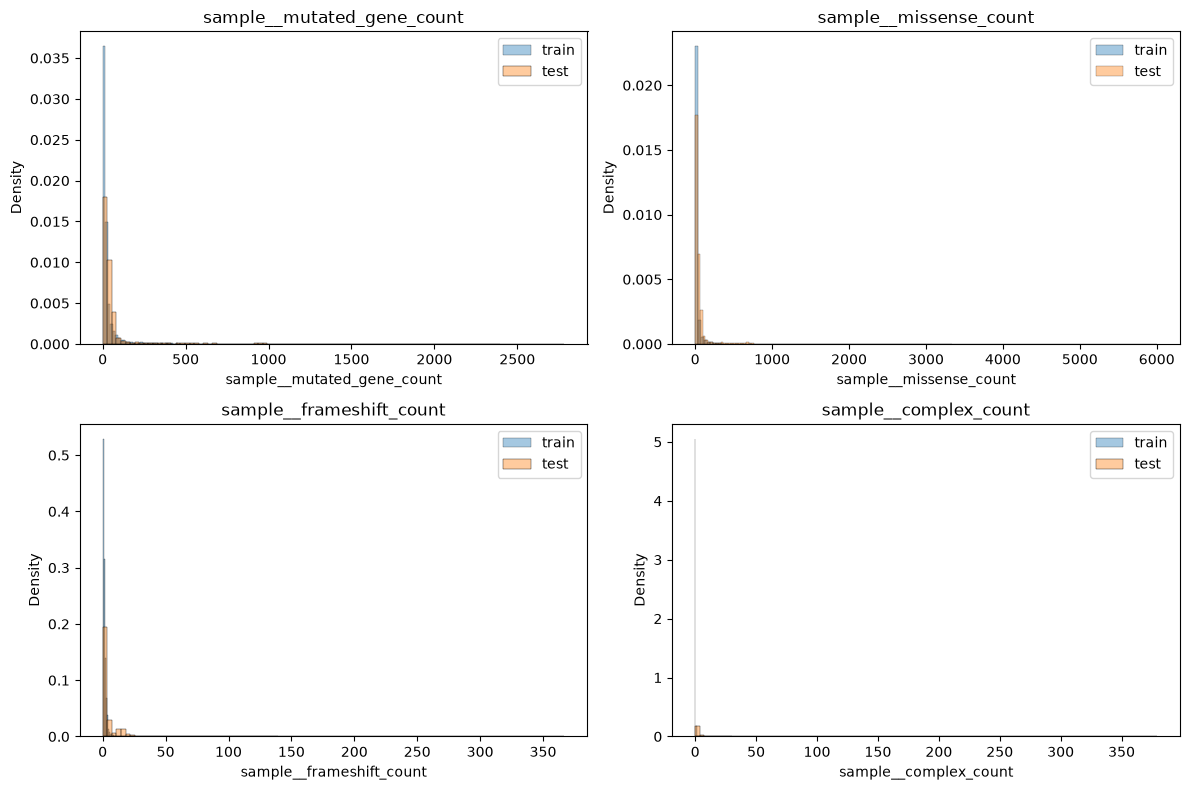

In [8]:
plot_columns = [
    "sample__mutated_gene_count",
    "sample__missense_count",
    "sample__frameshift_count",
    "sample__complex_count",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for column, axis in zip(plot_columns, axes.flat):
    sns.histplot(train_sample_features[column], label="train", stat="density", alpha=0.4, ax=axis)
    sns.histplot(test_sample_features[column], label="test", stat="density", alpha=0.4, ax=axis)
    axis.set_title(column)
    axis.legend()
plt.tight_layout()

## 4. 암종별 분포 확인 — EDA 전용

아래 분석은 가설 탐색에만 사용합니다. 여기서 발견한 타깃별 통계나 유전자 목록을 전체 train으로 고정해 피처 생성에 넣으면 검증 누출이 될 수 있습니다. 모델에 사용할 선택 규칙은 fold train 내부에서만 학습해야 합니다.

In [9]:
subclass_summary = (
    train_overview
    .groupby("SUBCLASS")[sample_names]
    .agg(["mean", "median"])
)
subclass_summary

sample__mutated_gene_count        sample__total_variant_count         \
                               mean median                        mean median   
SUBCLASS                                                                        
ACC                       39.430557   24.0                   43.611111   26.0   
BLCA                      70.490387   54.0                   75.923080   57.0   
BRCA                      17.437658    9.0                   19.510178   10.0   
CESC                      44.129032   20.0                   48.677418   21.0   
COAD                      73.121078   23.0                   86.412560   24.0   
DLBC                      67.421051   30.0                   78.657898   33.5   
GBMLGG                    12.535791   11.0                   12.863340   12.0   
HNSC                      40.569508   31.0                   42.506725   32.0   
KIPAN                     16.042719   15.0                   16.502913   15.0   
KIRC                      13.329341   13.0                   13.613772   13.0   
LAML                       3.056962    3.0                    3.113924    3.0   
LGG                        8.689957    8.0                    9.004367    8.0   
LIHC                      31.335443   25.0                   32.183544   25.0   
LUAD                      58.043480   40.5                   61.250000   42.0   
LUSC                      69.528091   57.0                   73.376404   59.0   
OV                        14.592885   12.0                   14.739130   13.0   
PAAD                      36.283333   14.0                   56.241665   14.0   
PCPG                       4.428571    4.0                    4.598639    4.0   
PRAD                       7.703008    6.0                    7.883459    6.0   
SARC                      12.833333    9.0                   13.853536    9.0   
SKCM                     132.532608   85.5                  177.507248   88.0   
STES                      81.841690   41.0                   89.738785   42.0   
TGCT                      16.717741   16.0                   16.919355   16.0   
THCA                       4.250000    4.0                    4.490741    4.0   
THYM                       4.377551    2.0                    4.551021    2.0   
UCEC                     133.969696   18.0                  179.636368   19.0   

         sample__multi_variant_gene_count        sample__missing_gene_count  \
                                     mean median                       mean   
SUBCLASS                                                                      
ACC                              3.138889    1.5                        0.0   
BLCA                             4.355769    3.0                        0.0   
BRCA                             1.662850    0.0                        0.0   
CESC                             3.754839    1.0                        0.0   
COAD                             8.798206    1.0                        0.0   
DLBC                             7.710526    2.0                        0.0   
GBMLGG                           0.297180    0.0                        0.0   
HNSC                             1.560538    1.0                        0.0   
KIPAN                            0.384466    0.0                        0.0   
KIRC                             0.239521    0.0                        0.0   
LAML                             0.056962    0.0                        0.0   
LGG                              0.288210    0.0                        0.0   
LIHC                             0.727848    0.0                        0.0   
LUAD                             2.760870    1.0                        0.0   
LUSC                             3.219101    1.5                        0.0   
OV                               0.122530    0.0                        0.0   
PAAD                             9.683333    0.0                        0.0   
PCPG                             0.156463    0.0                        0.0   


/var/folders/hb/_tdbtlhj5393hs74gqzd2f8w0000gn/T/ipykernel_11404/1982429909.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hb/_tdbtlhj5393hs74gqzd2f8w0000gn/T/ipykernel_11404/1982429909.py:16: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hb/_tdbtlhj5393hs74gqzd2f8w0000gn/T/ipykernel_11404/1982429909.py:16: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hb/_tdbtlhj5393hs74gqzd2f8w0000gn/T/ipykernel_11404/1982429909.py:16: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hb/_tdbtlhj5393hs74gqzd2f8w0000gn/T/ipykernel_11404/1982429909.py:16: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hb/_tdbtlhj5393hs74gqzd2f8w0000gn/T/ipyk

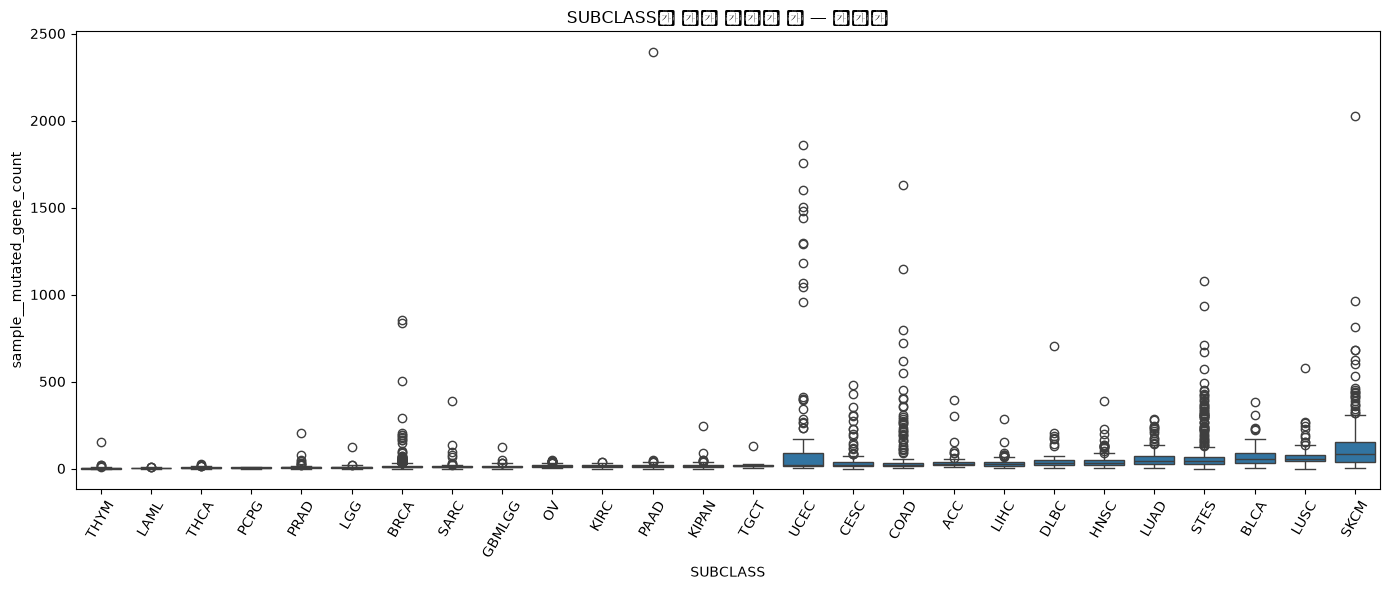

In [10]:
plt.figure(figsize=(14, 6))
subclass_order = (
    train_overview.groupby("SUBCLASS")["sample__mutated_gene_count"]
    .median()
    .sort_values()
    .index
)
sns.boxplot(
    data=train_overview,
    x="SUBCLASS",
    y="sample__mutated_gene_count",
    order=subclass_order,
)
plt.xticks(rotation=60)
plt.title("SUBCLASS별 변이 유전자 수 — 탐색용")
plt.tight_layout()

## 5. 특정 유전자 피처 확인

In [11]:
def gene_feature_frame(gene: str, include_raw: bool = True) -> pd.DataFrame:
    indices = [
        index for index, name in enumerate(feature_names)
        if name.startswith(f"{gene}__")
    ]
    if not indices:
        raise KeyError(f"피처 목록에 없는 유전자입니다: {gene}")

    frame = pd.DataFrame(
        X_train[:, indices].toarray(),
        columns=[feature_names[index] for index in indices],
    )
    frame = pd.concat([train_ids, labels, frame], axis=1)
    if include_raw:
        raw = pd.read_csv(
            RAW_DIR / "train.csv",
            usecols=["ID", gene],
            dtype=str,
            keep_default_na=False,
        )
        frame = frame.merge(raw, on="ID", how="left", validate="one_to_one")
    return frame


tp53 = gene_feature_frame("TP53")
tp53.query("TP53__mutated == 1").head(20)

,ID,SUBCLASS,TP53__mutated,TP53__missense,TP53__synonymous,TP53__nonsense,TP53__frameshift,TP53__complex,TP53__missing,TP53
1,TRAIN_0001,SARC,1.0,1.0,0.0,0.0,0.0,0.0,0.0,M237I
4,TRAIN_0004,GBMLGG,1.0,1.0,0.0,0.0,0.0,0.0,0.0,M246R
13,TRAIN_0013,PAAD,1.0,0.0,0.0,0.0,1.0,0.0,0.0,S269fs
14,TRAIN_0014,SKCM,1.0,0.0,0.0,1.0,0.0,0.0,0.0,R196*
21,TRAIN_0021,UCEC,1.0,1.0,0.0,0.0,0.0,0.0,0.0,D281Y
31,TRAIN_0031,GBMLGG,1.0,1.0,0.0,0.0,0.0,0.0,0.0,R273C
32,TRAIN_0032,HNSC,1.0,0.0,0.0,1.0,0.0,0.0,0.0,E298*
36,TRAIN_0036,LGG,1.0,1.0,0.0,0.0,0.0,0.0,0.0,P278L
37,TRAIN_0037,LUSC,1.0,0.0,0.0,1.0,0.0,0.0,0.0,R196*
38,TRAIN_0038,LUSC,1.0,1.0,0.0,0.0,0.0,0.0,0.0,D281Y


In [12]:
pd.crosstab(
    tp53["SUBCLASS"],
    tp53["TP53__mutated"],
    normalize="index",
).rename(columns={0.0: "WT 비율", 1.0: "변이 비율"}).sort_values("변이 비율", ascending=False)

TP53__mutated,WT 비율,변이 비율
SUBCLASS,,
OV,0.249012,0.750988
LUSC,0.286517,0.713483
HNSC,0.340807,0.659193
PAAD,0.341667,0.658333
STES,0.435356,0.564644
BLCA,0.471154,0.528846
COAD,0.484305,0.515695
LGG,0.493450,0.506550
LUAD,0.581522,0.418478


## 6. 전체 희소 피처의 빈도 확인

전체 행렬은 희소 상태로 합계를 계산한 뒤 작은 결과만 pandas로 변환합니다.

In [13]:
feature_nonzero = np.asarray((X_train != 0).sum(axis=0)).ravel()
feature_frequency = pd.DataFrame({
    "feature": feature_names,
    "nonzero_samples": feature_nonzero,
})
feature_frequency["sample_ratio"] = feature_frequency["nonzero_samples"] / X_train.shape[0]

feature_frequency[
    ~feature_frequency["feature"].str.startswith("sample__")
].nlargest(30, "nonzero_samples")

,feature,nonzero_samples,sample_ratio
28758,TP53__mutated,1770,0.285438
28759,TP53__missense,1299,0.209482
20848,PIK3CA__mutated,686,0.110627
20849,PIK3CA__missense,665,0.107241
24292,RYR2__mutated,643,0.103693
27358,SYNE1__mutated,642,0.103532
20008,PCLO__mutated,593,0.095630
24293,RYR2__missense,504,0.081277
24285,RYR1__mutated,473,0.076278
27359,SYNE1__missense,467,0.075310


## 7. 새로운 피처 아이디어 실험 공간

여기서는 pandas로 아이디어를 확인합니다. 채택할 피처만 `src/open_cancer/mutation_features.py`에 구현하고 fixture 테스트를 추가합니다.

후보 예시:

- 변이 유형 비율 (`frameshift / total_variant_count` 등)
- 유전자별 복수 변이 여부
- 아미노산 성질 변화 집계
- fold train 안에서만 선택한 암종 구분력이 높은 유전자

주의: `SUBCLASS`를 보고 선택한 피처를 전체 데이터에 바로 고정하지 않습니다.

In [ ]:
# 예시: 분모가 0인 경우를 안전하게 처리한 변이 유형 비율
idea_frame = train_overview[["ID", "SUBCLASS"]].copy()
denominator = train_overview["sample__total_variant_count"].replace(0, np.nan)
idea_frame["frameshift_ratio"] = (
    train_overview["sample__frameshift_count"] / denominator
).fillna(0)
idea_frame["nonsense_ratio"] = (
    train_overview["sample__nonsense_count"] / denominator
).fillna(0)
idea_frame.describe(include="all")

## 다음 단계

1. Notebook에서 피처 아이디어와 train/test 분포를 확인합니다.
2. 채택할 로직을 `src/open_cancer/mutation_features.py`에 반영합니다.
3. `uv run pytest`와 `uv run python scripts/build_mutation_features.py`를 실행합니다.
4. 공식 OOF 비교를 시작할 때는 Experiment Issue와 `RUN_MODE="experiment"`를 사용하고 실제 결과만 History에 기록합니다.